# Implementing Nelder-Mead method

1. Implement the two and three dimensional versions of Nelder-Mead method. Use a programming language of your choice.

## Algorithm

Each iteration maintains a simplex of $n+1$ points sorted by function value $f(x_1) \leq \cdots \leq f(x_{n+1})$. The centroid $\bar{x}$ is computed over all points except the worst. The following steps are attempted in order, each replacing the worst point if successful.

1. **Reflection.** Reflect the worst point through the centroid: $x_r = 2\bar{x} - x_{n+1}$. If $f(x_r)$ is between the best and second-worst values, accept it.

2. **Expansion.** If the reflected point is better than the best, try to go further: $x_e = 2x_r - \bar{x}$. Accept whichever of $x_e$ and $x_r$ is lower.

3. **Outside contraction.** If the reflected point is better than the worst but not better than the second-worst, contract between the centroid and the reflected point: $x_c = \frac{\bar{x} + x_r}{2}$. Accept if $f(x_c) \leq f(x_r)$, otherwise shrink.

4. **Inside contraction.** If the reflected point is worse than the worst, contract between the centroid and the worst point: $x_c = \frac{\bar{x} + x_{n+1}}{2}$. Accept if $f(x_c) < f(x_{n+1})$, otherwise shrink.

5. **Shrink.** If contraction failed, pull all points except the best halfway toward the best: $x_i \leftarrow \frac{x_1 + x_i}{2}$.

The standard parameters are $\alpha = 1$ (reflection), $\gamma = 2$ (expansion), $\rho = 0.5$ (contraction), $\sigma = 0.5$ (shrink).

In [1]:
import numpy as np
np.seterr(all='ignore')


def nelder_mead_2d(f, x0, diameter=1.0, max_iter=1000, tol=1e-8):
    """Minimize f: R^2 -> R using the Nelder-Mead simplex method.

    Args:
        f: objective function accepting a 1D array of length 2
        x0: starting point, array-like of length 2
        diameter: initial simplex size. The right value is problem-dependent,
                  tune it to match the expected distance from x0 to the minimum.
        max_iter: maximum number of iterations
        tol: stop when the function value spread across the simplex falls below this value

    Returns:
        (x, fval): best point found and its function value
    """
    x0 = np.array(x0, dtype=float)
    a = x0
    b = x0 + diameter * np.array([1., 0.])
    c = x0 + diameter * np.array([0., 1.])
    simplex = [a, b, c]

    for _ in range(max_iter):
        simplex.sort(key=f)
        best, second, worst = simplex
        f_best, f_second, f_worst = f(best), f(second), f(worst)

        if f_worst - f_best < tol:
            break

        centroid = (best + second) / 2

        # step 1: reflection
        reflected = 2 * centroid - worst
        f_reflected = f(reflected)

        if f_reflected < f_best:
            # step 2: expansion
            expanded = 2 * reflected - centroid
            simplex[2] = expanded if f(expanded) < f_reflected else reflected
        elif f_reflected < f_second:
            simplex[2] = reflected
        elif f_reflected < f_worst:
            # step 3: outside contraction
            contracted = (centroid + reflected) / 2
            if f(contracted) <= f_reflected:
                simplex[2] = contracted
            else:
                # step 5: shrink
                simplex[1] = (best + second) / 2
                simplex[2] = (best + worst) / 2
        else:
            # step 4: inside contraction
            contracted = (centroid + worst) / 2
            if f(contracted) < f_worst:
                simplex[2] = contracted
            else:
                # step 5: shrink
                simplex[1] = (best + second) / 2
                simplex[2] = (best + worst) / 2

    simplex.sort(key=f)
    return simplex[0], f(simplex[0])


def nelder_mead_3d(f, x0, diameter=1.0, max_iter=1000, tol=1e-8):
    """Minimize f: R^3 -> R using the Nelder-Mead simplex method.

    Args:
        f: objective function accepting a 1D array of length 3
        x0: starting point, array-like of length 3
        diameter: initial simplex size. The right value is problem-dependent,
                  tune it to match the expected distance from x0 to the minimum.
        max_iter: maximum number of iterations
        tol: stop when the function value spread across the simplex falls below this value

    Returns:
        (x, fval): best point found and its function value
    """
    x0 = np.array(x0, dtype=float)
    a = x0
    b = x0 + diameter * np.array([1., 0., 0.])
    c = x0 + diameter * np.array([0., 1., 0.])
    d = x0 + diameter * np.array([0., 0., 1.])
    simplex = [a, b, c, d]

    for _ in range(max_iter):
        simplex.sort(key=f)
        best, second, third, worst = simplex
        f_best, f_second, f_third, f_worst = f(best), f(second), f(third), f(worst)

        if f_worst - f_best < tol:
            break

        centroid = (best + second + third) / 3

        # step 1: reflection
        reflected = 2 * centroid - worst
        f_reflected = f(reflected)

        if f_reflected < f_best:
            # step 2: expansion
            expanded = 2 * reflected - centroid
            simplex[3] = expanded if f(expanded) < f_reflected else reflected
        elif f_reflected < f_third:
            simplex[3] = reflected
        elif f_reflected < f_worst:
            # step 3: outside contraction
            contracted = (centroid + reflected) / 2
            if f(contracted) <= f_reflected:
                simplex[3] = contracted
            else:
                # step 5: shrink
                simplex[1] = (best + second) / 2
                simplex[2] = (best + third) / 2
                simplex[3] = (best + worst) / 2
        else:
            # step 4: inside contraction
            contracted = (centroid + worst) / 2
            if f(contracted) < f_worst:
                simplex[3] = contracted
            else:
                # step 5: shrink
                simplex[1] = (best + second) / 2
                simplex[2] = (best + third) / 2
                simplex[3] = (best + worst) / 2

    simplex.sort(key=f)
    return simplex[0], f(simplex[0])

**One step beyond:** Why fix the dimension? Surely you can pass the dimension as a parameter or better still compute it on the fly.

There is no reason to fix the dimension. Nelder-Mead uses $n + 1$ simplex points for a function in $\mathbb{R}^n$, so the dimension can be inferred directly from the starting point with `n = len(x0)`. The initial simplex is then built from `x0` and small shifts along each coordinate axis.

In [2]:
def nelder_mead(f, x0, diameter=1.0, max_iter=1000, tol=1e-8):
    """Minimize f: R^n -> R using the Nelder-Mead simplex method.

    The dimension n is inferred from x0. The initial simplex has n+1 points:
    x0 and x0 shifted by diameter along each coordinate axis.

    Args:
        f: objective function accepting a 1D array of length n
        x0: starting point, array-like of length n
        diameter: initial simplex size. The right value is problem-dependent,
                  tune it to match the expected distance from x0 to the minimum.
        max_iter: maximum number of iterations
        tol: stop when the function value spread across the simplex falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x0 = np.array(x0, dtype=float)
    n = len(x0)

    simplex = [x0] + [x0 + diameter * np.eye(n)[i] for i in range(n)]

    iters = 0
    for _ in range(max_iter):
        simplex.sort(key=f)
        f_values = [f(x) for x in simplex]

        if f_values[-1] - f_values[0] < tol:
            break

        best = simplex[0]
        worst = simplex[-1]
        f_best = f_values[0]
        f_worst = f_values[-1]
        f_second_worst = f_values[-2]

        centroid = np.mean(simplex[:-1], axis=0)

        # step 1: reflection
        reflected = 2 * centroid - worst
        f_reflected = f(reflected)

        if f_reflected < f_best:
            # step 2: expansion
            expanded = 2 * reflected - centroid
            simplex[-1] = expanded if f(expanded) < f_reflected else reflected
        elif f_reflected < f_second_worst:
            simplex[-1] = reflected
        elif f_reflected < f_worst:
            # step 3: outside contraction
            contracted = (centroid + reflected) / 2
            if f(contracted) <= f_reflected:
                simplex[-1] = contracted
            else:
                # step 5: shrink
                simplex[1:] = [(best + x) / 2 for x in simplex[1:]]
        else:
            # step 4: inside contraction
            contracted = (centroid + worst) / 2
            if f(contracted) < f_worst:
                simplex[-1] = contracted
            else:
                # step 5: shrink
                simplex[1:] = [(best + x) / 2 for x in simplex[1:]]

        iters += 1

    simplex.sort(key=f)
    return simplex[0], f(simplex[0]), iters

# Comparing Nelder-Mead with gradient descent methods

These functions are taken from M2 GD.2/6a,b,c. For the Nelder-Mead method choose starting samples of different diameters, one of the starting sample points should match the one given in the original homework.

### Function A

$$f(x, y, z) = (x - z)^2 + (2y + z)^2 + (4x - 2y + z)^2 + x + y$$

A quadratic function in three variables. The minimum can be found exactly since the Hessian is constant. Starting points: $(0, 0, 0)$ (closer to the minimum) and $(1, 1, 0)$.

In [3]:
def f_a(point):
    x, y, z = point
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def grad_a(point):
    x, y, z = point
    r1 = x - z
    r2 = 2*y + z
    r3 = 4*x - 2*y + z
    return np.array([
        2*r1 + 8*r3 + 1,
        4*r2 - 4*r3 + 1,
        -2*r1 + 2*r2 + 2*r3,
    ])

def hess_a(point):
    return np.array([
        [34, -16,  6],
        [-16, 16,  0],
        [  6,  0,  6],
    ])

spoint_a1 = np.array([0.0, 0.0, 0.0])
spoint_a2 = np.array([1.0, 1.0, 0.0])

### Function B

$$f(x, y, z) = (x - 1)^2 + (y - 1)^2 + 100(y - x^2)^2 + 100(z - y^2)^2$$

A Rosenbrock-like function in three variables with a curved, narrow valley. The global minimum is at $(1, 1, 1)$ with $f = 0$. Starting points: $(1.2, 1.2, 1.2)$ (closer to the minimum) and $(-1, 1.2, 1.2)$.

In [4]:
def f_b(point):
    x, y, z = point
    return (x - 1)**2 + (y - 1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def grad_b(point):
    x, y, z = point
    u = y - x**2
    v = z - y**2
    return np.array([
        2*(x - 1) - 400*x*u,
        2*(y - 1) + 200*u - 400*y*v,
        200*v,
    ])

def hess_b(point):
    x, y, z = point
    u = y - x**2
    v = z - y**2
    return np.array([
        [2 - 400*u + 800*x**2,          -400*x,      0],
        [         -400*x,      202 - 400*v + 800*y**2, -400*y],
        [              0,                   -400*y,    200],
    ])

spoint_b1 = np.array([1.2, 1.2, 1.2])
spoint_b2 = np.array([-1.0, 1.2, 1.2])

### Function C

$$f(x, y) = (1.5 - x + xy)^2 + (2.25 - x + xy^2)^2 + (2.625 - x + xy^3)^2$$

The Beale function in two variables. The global minimum is at $(3, 0.5)$ with $f = 0$. Starting points: $(1, 1)$ (closer to the minimum) and $(4.5, 4.5)$.

In [5]:
def f_c(point):
    x, y = point
    r1 = 1.5 - x + x*y
    r2 = 2.25 - x + x*y**2
    r3 = 2.625 - x + x*y**3
    return r1**2 + r2**2 + r3**2

def grad_c(point):
    x, y = point
    r1 = 1.5 - x + x*y
    r2 = 2.25 - x + x*y**2
    r3 = 2.625 - x + x*y**3
    return np.array([
        2*r1*(y - 1) + 2*r2*(y**2 - 1) + 2*r3*(y**3 - 1),
        2*r1*x + 2*r2*(2*x*y) + 2*r3*(3*x*y**2),
    ])

def hess_c(point):
    x, y = point
    r1 = 1.5 - x + x*y
    r2 = 2.25 - x + x*y**2
    r3 = 2.625 - x + x*y**3
    h_xx = 2*(y - 1)**2 + 2*(y**2 - 1)**2 + 2*(y**3 - 1)**2
    h_yy = 2*x**2 + 2*(2*x*y)**2 + 4*x*r2 + 2*(3*x*y**2)**2 + 12*x*y*r3
    h_xy = (2*(y - 1)*x + 2*r1
            + 2*(y**2 - 1)*(2*x*y) + 4*y*r2
            + 2*(y**3 - 1)*(3*x*y**2) + 6*y**2*r3)
    return np.array([
        [h_xx, h_xy],
        [h_xy, h_yy],
    ])

spoint_c1 = np.array([1.0, 1.0])
spoint_c2 = np.array([4.5, 4.5])

### Visualization

Each function is shown as a 2D heatmap over a region that contains both starting points and the minimum. For $f_a$ and $f_b$, the third variable $z$ is fixed at the optimum. The white cross marks the minimum and the black crosses mark the starting points.

In [6]:
import matplotlib.pyplot as plt


def visualize_f(f, x_range, y_range, title, z_fixed=None, spoints=None, minimum=None, resolution=300):
    """Plot a 2D heatmap of f.

    Args:
        f: objective function
        x_range: (xmin, xmax) for the x axis
        y_range: (ymin, ymax) for the y axis
        title: plot title
        z_fixed: if not None, fix z at this value (for 3D functions)
        spoints: list of starting points to mark with black crosses
        minimum: known minimum point to mark with a white cross
        resolution: grid resolution
    """
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)

    if z_fixed is not None:
        Z = np.vectorize(lambda xi, yi: f(np.array([xi, yi, z_fixed])))(X, Y)
    else:
        Z = np.vectorize(lambda xi, yi: f(np.array([xi, yi])))(X, Y)

    plt.figure(figsize=(5, 4))
    plt.pcolormesh(X, Y, Z, cmap='RdYlBu_r', shading='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')

    if minimum is not None:
        plt.plot(minimum[0], minimum[1], 'w+', markersize=12, markeredgewidth=2)
    if spoints is not None:
        for sp in spoints:
            plt.plot(sp[0], sp[1], 'k+', markersize=12, markeredgewidth=2)

    plt.tight_layout()
    plt.show()

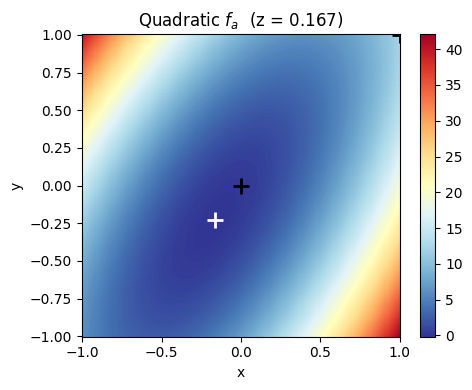

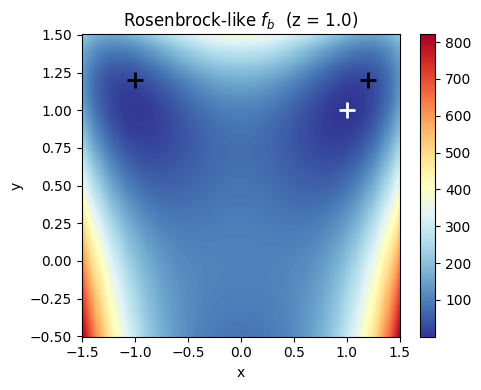

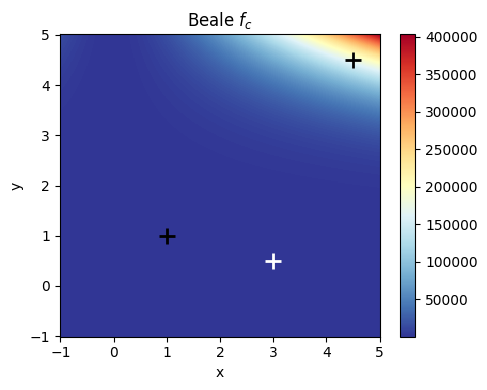

In [7]:
x_opt_a = -np.linalg.solve(hess_a(np.zeros(3)), grad_a(np.zeros(3)))

visualize_f(f_a, (-1, 1), (-1, 1),
            f'Quadratic $f_a$  (z = {x_opt_a[2]:.3f})',
            z_fixed=x_opt_a[2],
            spoints=[spoint_a1[:2], spoint_a2[:2]],
            minimum=x_opt_a[:2])

visualize_f(f_b, (-1.5, 1.5), (-0.5, 1.5),
            'Rosenbrock-like $f_b$  (z = 1.0)',
            z_fixed=1.0,
            spoints=[spoint_b1[:2], spoint_b2[:2]],
            minimum=np.array([1.0, 1.0]))

visualize_f(f_c, (-1, 5), (-1, 5),
            'Beale $f_c$',
            spoints=[spoint_c1, spoint_c2],
            minimum=np.array([3.0, 0.5]))

2. Qualitatively compare Nelder-Mead method with the methods you have implemented in HW GD.2 (GD, Polyak GD, Nesterov GD, AdaGrad GD, Newton, BFGS).

The following methods are implemented for comparison. All use gradient norm $\|\nabla f(x)\| < \varepsilon$ as the stopping criterion.

| Method | Update rule |
|---|---|
| GD | $x \leftarrow x - \alpha \nabla f(x)$ |
| Polyak GD | $x \leftarrow x - \alpha \nabla f(x) + \mu (x - x_\text{prev})$ |
| Nesterov GD | $y = x + \mu(x - x_\text{prev}),\quad x \leftarrow y - \alpha \nabla f(y)$ |
| AdaGrad | $G \mathrel{+}= \nabla f(x)^2,\quad x \leftarrow x - \frac{\alpha}{\sqrt{G + \varepsilon}} \nabla f(x)$ |
| Newton | $x \leftarrow x - \beta H_f(x)^{-1} \nabla f(x)$ |
| BFGS | $x \leftarrow x - \alpha_k H_k^{-1} \nabla f(x)$, with $H_k^{-1}$ updated by rank-2 formula |

In [8]:
def gradient_descent(f, grad, x0, lr=0.001, max_iter=1000, tol=1e-8):
    """Gradient descent with fixed learning rate.

    Args:
        f: objective function
        grad: gradient function
        x0: starting point
        lr: learning rate
        max_iter: maximum number of iterations
        tol: stop when the gradient norm falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    iters = 0
    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - lr * g
        iters += 1
    return x, f(x), iters


def polyak_gd(f, grad, x0, lr=0.001, momentum=0.9, max_iter=1000, tol=1e-8):
    """Gradient descent with momentum (heavy ball). Accumulates past updates to
    accelerate progress in consistent directions and dampen oscillations.

    Args:
        f: objective function
        grad: gradient function
        x0: starting point
        lr: learning rate
        momentum: momentum coefficient
        max_iter: maximum number of iterations
        tol: stop when the gradient norm falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    iters = 0
    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        x_next = x - lr * g + momentum * (x - x_prev)
        x_prev = x
        x = x_next
        iters += 1
    return x, f(x), iters


def nesterov_gd(f, grad, x0, lr=0.001, momentum=0.9, max_iter=1000, tol=1e-8):
    """Like Polyak GD, but evaluates the gradient at a lookahead point rather than at x.
    This gives a better descent direction and provably improves the convergence rate.

    Args:
        f: objective function
        grad: gradient function
        x0: starting point
        lr: learning rate
        momentum: momentum coefficient
        max_iter: maximum number of iterations
        tol: stop when the gradient norm at the lookahead falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    iters = 0
    for _ in range(max_iter):
        lookahead = x + momentum * (x - x_prev)
        g = grad(lookahead)
        if np.linalg.norm(g) < tol:
            break
        x_next = lookahead - lr * g
        x_prev = x
        x = x_next
        iters += 1
    return x, f(x), iters


def adagrad(f, grad, x0, lr=0.01, max_iter=1000, tol=1e-8):
    """Gradient descent with a per-coordinate adaptive learning rate, scaled by
    cumulative squared gradients. Reduces steps for frequently large gradients.

    Args:
        f: objective function
        grad: gradient function
        x0: starting point
        lr: global learning rate
        max_iter: maximum number of iterations
        tol: stop when the gradient norm falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    sq_grad_sum = np.zeros_like(x)
    eps = 1e-8
    iters = 0
    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        sq_grad_sum = sq_grad_sum + g**2
        x = x - lr / np.sqrt(sq_grad_sum + eps) * g
        iters += 1
    return x, f(x), iters


def newton(f, grad, hess, x0, step_scale=1.0, max_iter=1000, tol=1e-8):
    """Newton's method. Scales the gradient by the inverse Hessian to account for
    curvature, giving quadratic convergence near the minimum.

    Args:
        f: objective function
        grad: gradient function
        hess: Hessian function
        x0: starting point
        step_scale: multiplier on the Newton step
        max_iter: maximum number of iterations
        tol: stop when the gradient norm falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    iters = 0
    for _ in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - step_scale * np.linalg.solve(hess(x), g)
        iters += 1
    return x, f(x), iters


def bfgs(f, grad, x0, max_iter=1000, tol=1e-8):
    """Quasi-Newton method. Approximates the inverse Hessian from gradient differences
    using a rank-2 update, with a backtracking line search for sufficient decrease.

    Args:
        f: objective function
        grad: gradient function
        x0: starting point
        max_iter: maximum number of iterations
        tol: stop when the gradient norm falls below this value

    Returns:
        (x, fval, iters): best point found, its function value, and iteration count
    """
    x = np.array(x0, dtype=float)
    n = len(x)
    H_inv = np.eye(n)
    g = grad(x)
    iters = 0

    for _ in range(max_iter):
        if np.linalg.norm(g) < tol:
            break

        direction = H_inv @ g

        # backtracking Armijo line search
        lr = 1.0
        f_x = f(x)
        while f(x - lr * direction) > f_x - 1e-4 * lr * (g @ direction):
            lr *= 0.5
            if lr < 1e-16:
                break

        step = -lr * direction
        x_next = x + step
        grad_next = grad(x_next)
        grad_diff = grad_next - g

        if step @ grad_diff > 1e-10:
            rho = 1.0 / (step @ grad_diff)
            V = np.eye(n) - rho * np.outer(step, grad_diff)
            H_inv = V @ H_inv @ V.T + rho * np.outer(step, step)

        x = x_next
        g = grad_next
        iters += 1

    return x, f(x), iters

**One step beyond:** Qualitatively compare? Think of all possible aspects of comparison. The word all in the previous sentence is maybe too ambitious, several is a more appropriate choice.

The methods are compared across the following criteria:

1. **Information used.** Function values only, gradients, or gradients and Hessians.
2. **Convergence speed.** Whether the method converges and how many iterations it takes. A method is considered converged if $\|x_\text{final} - x^*\| < 0.1$. This is a coarse check that identifies whether the method found the right optimum, while the function value gap measures the precision separately.
3. **Convergence quality.** How close the final function value is to the known minimum, measured by $f(x_\text{final}) - f(x^*)$.
4. **Sensitivity to starting point.** Each function is tested from two starting points.
5. **Sensitivity to parameters.** Learning rate (GD variants) and simplex diameter (Nelder-Mead) are tested at small, medium, and large values: $\alpha \in \{0.0001, 0.001, 0.01\}$ and $d \in \{0.1, 1.0, 3.0\}$.

In [9]:
import pandas as pd

CONV_THRESHOLD = 1e-1

x_star_a = x_opt_a
x_star_b = np.array([1., 1., 1.])
x_star_c = np.array([3., 0.5])

problems = [
    dict(name='f_a  sp1', f=f_a, grad=grad_a, hess=hess_a, x0=spoint_a1, x_star=x_star_a, f_star=f_a(x_star_a)),
    dict(name='f_a  sp2', f=f_a, grad=grad_a, hess=hess_a, x0=spoint_a2, x_star=x_star_a, f_star=f_a(x_star_a)),
    dict(name='f_b  sp1', f=f_b, grad=grad_b, hess=hess_b, x0=spoint_b1, x_star=x_star_b, f_star=0.0),
    dict(name='f_b  sp2', f=f_b, grad=grad_b, hess=hess_b, x0=spoint_b2, x_star=x_star_b, f_star=0.0),
    dict(name='f_c  sp1', f=f_c, grad=grad_c, hess=hess_c, x0=spoint_c1, x_star=x_star_c, f_star=0.0),
    dict(name='f_c  sp2', f=f_c, grad=grad_c, hess=hess_c, x0=spoint_c2, x_star=x_star_c, f_star=0.0),
]

METHOD_NAMES = ['GD', 'Polyak', 'Nesterov', 'AdaGrad', 'Newton', 'BFGS', 'NM']


def run_method(name, problem, lr=None, diameter=None):
    """Run a named method on problem and return (x, fval, iters)."""
    f, grad, hess, x0 = problem['f'], problem['grad'], problem['hess'], problem['x0']
    if name == 'GD':       return gradient_descent(f, grad, x0, lr=lr or 0.001)
    if name == 'Polyak':   return polyak_gd(f, grad, x0, lr=lr or 0.001)
    if name == 'Nesterov': return nesterov_gd(f, grad, x0, lr=lr or 0.001)
    if name == 'AdaGrad':  return adagrad(f, grad, x0, lr=lr or 0.01)
    if name == 'Newton':   return newton(f, grad, hess, x0)
    if name == 'BFGS':     return bfgs(f, grad, x0)
    if name == 'NM':       return nelder_mead(f, x0, diameter=diameter or 1.0)


def result_str(x, fval, problem):
    """Format result as 'converged_symbol  f_final - f*'."""
    converged = np.linalg.norm(x - problem['x_star']) < CONV_THRESHOLD
    quality   = fval - problem['f_star']
    return ('✓' if converged else '✗') + f'  {quality:.2e}'

In [10]:
# run all methods with default parameters and cache results
default_results = {}
for problem in problems:
    for name in METHOD_NAMES:
        default_results[(problem['name'], name)] = run_method(name, problem)

In [11]:
# comparison 1: information used by each method

info = {
    'GD':       {'f':  '✓', '∇f':    '✓', '∇²f':       ''},
    'Polyak':   {'f':  '✓', '∇f':    '✓', '∇²f':       ''},
    'Nesterov': {'f':  '✓', '∇f':    '✓', '∇²f':       ''},
    'AdaGrad':  {'f':  '✓', '∇f':    '✓', '∇²f':       ''},
    'Newton':   {'f':  '✓', '∇f':    '✓', '∇²f':    '✓'},
    'BFGS':     {'f':  '✓', '∇f':    '✓', '∇²f': 'approx'},
    'NM':       {'f':  '✓', '∇f':     '', '∇²f':       ''},
}

df = pd.DataFrame(info).T
df.index.name = 'method'
display(df)

,f,∇f,∇²f
method,,,
GD,✓,✓,
Polyak,✓,✓,
Nesterov,✓,✓,
AdaGrad,✓,✓,
Newton,✓,✓,✓
BFGS,✓,✓,approx
NM,✓,,


In [12]:
# comparisons 2 and 3: convergence speed and quality
# for each problem: did the method find the right optimum, how many iterations, and how close is f?

for problem in problems:
    data = {}
    for name in METHOD_NAMES:
        x, fval, iters = default_results[(problem['name'], name)]
        conv = np.linalg.norm(x - problem['x_star']) < CONV_THRESHOLD
        data[name] = {
            'converged':  '✓' if conv else '✗',
            'iters':      iters,
            '||x - x*||': f'{np.linalg.norm(x - problem["x_star"]):.2e}',
            'f - f*':     f'{fval - problem["f_star"]:.2e}',
        }
    df = pd.DataFrame(data).T
    df.index.name = problem['name']
    display(df)

,converged,iters,||x - x*||,f - f*
f_a sp1,,,,
GD,✓,1000,1.70e-02,4.19e-04
Polyak,✓,354,1.48e-09,2.78e-17
Nesterov,✓,365,3.50e-09,5.55e-17
AdaGrad,✓,1000,8.84e-05,1.49e-08
Newton,✓,1,0.00e+00,0.00e+00
BFGS,✓,7,1.36e-11,0.00e+00
NM,✓,60,9.86e-06,2.48e-10


,converged,iters,||x - x*||,f - f*
f_a sp2,,,,
GD,✓,1000,6.63e-02,6.35e-03
Polyak,✓,368,1.53e-09,5.55e-17
Nesterov,✓,392,3.51e-09,2.78e-17
AdaGrad,✗,1000,1.10e+00,2.52e+00
Newton,✓,1,1.84e-16,2.78e-17
BFGS,✓,8,1.07e-09,0.00e+00
NM,✓,62,2.47e-05,3.58e-09


,converged,iters,||x - x*||,f - f*
f_b sp1,,,,
GD,✗,1000,1.91e-01,8.14e-03
Polyak,✓,1000,6.13e-04,8.93e-08
Nesterov,✓,1000,5.78e-03,5.60e-03
AdaGrad,✗,1000,3.35e-01,2.39e-02
Newton,✓,8,2.13e-13,6.71e-25
BFGS,✓,23,1.17e-10,1.32e-20
NM,✓,90,3.26e-05,1.05e-09


,converged,iters,||x - x*||,f - f*
f_b sp2,,,,
GD,✗,1000,1.92e+00,3.44e+00
Polyak,✓,1000,1.24e-02,3.66e-05
Nesterov,✓,1000,7.97e-03,1.51e-05
AdaGrad,✗,1000,2.06e+00,4.21e+00
Newton,✓,33,1.12e-09,2.99e-19
BFGS,✓,53,8.17e-11,1.02e-20
NM,✓,227,4.57e-05,3.41e-09


,converged,iters,||x - x*||,f - f*
f_c sp1,,,,
GD,✗,1000,5.45e-01,8.09e-02
Polyak,✓,1000,1.61e-02,3.99e-05
Nesterov,✓,1000,1.63e-02,4.07e-05
AdaGrad,✗,1000,1.26e+00,2.53e+00
Newton,✗,1,3.04e+00,1.42e+01
BFGS,✓,15,6.23e-09,6.09e-18
NM,✓,40,1.24e-04,2.36e-09


,converged,iters,||x - x*||,f - f*
f_c sp2,,,,
GD,✗,1000,nan,nan
Polyak,✗,1000,nan,nan
Nesterov,✗,1000,nan,nan
AdaGrad,✗,1000,3.61e+00,6.55e+04
Newton,✗,13,3.04e+00,1.42e+01
BFGS,✗,1000,7.64e+04,7.31e+00
NM,✓,40,3.09e-04,1.46e-08


In [13]:
# comparison 4: sensitivity to starting point
# for each function: how do results change between sp1 and sp2?

for i in range(0, len(problems), 2):
    p1, p2 = problems[i], problems[i + 1]
    fname = p1['name'].split('  ')[0]
    data = {}
    for name in METHOD_NAMES:
        x1, fval1, _ = default_results[(p1['name'], name)]
        x2, fval2, _ = default_results[(p2['name'], name)]
        data[name] = {
            'sp1': result_str(x1, fval1, p1),
            'sp2': result_str(x2, fval2, p2),
        }
    df = pd.DataFrame(data).T
    df.index.name = fname
    display(df)

,sp1,sp2
f_a,,
GD,✓ 4.19e-04,✓ 6.35e-03
Polyak,✓ 2.78e-17,✓ 5.55e-17
Nesterov,✓ 5.55e-17,✓ 2.78e-17
AdaGrad,✓ 1.49e-08,✗ 2.52e+00
Newton,✓ 0.00e+00,✓ 2.78e-17
BFGS,✓ 0.00e+00,✓ 0.00e+00
NM,✓ 2.48e-10,✓ 3.58e-09


,sp1,sp2
f_b,,
GD,✗ 8.14e-03,✗ 3.44e+00
Polyak,✓ 8.93e-08,✓ 3.66e-05
Nesterov,✓ 5.60e-03,✓ 1.51e-05
AdaGrad,✗ 2.39e-02,✗ 4.21e+00
Newton,✓ 6.71e-25,✓ 2.99e-19
BFGS,✓ 1.32e-20,✓ 1.02e-20
NM,✓ 1.05e-09,✓ 3.41e-09


,sp1,sp2
f_c,,
GD,✗ 8.09e-02,✗ nan
Polyak,✓ 3.99e-05,✗ nan
Nesterov,✓ 4.07e-05,✗ nan
AdaGrad,✗ 2.53e+00,✗ 6.55e+04
Newton,✗ 1.42e+01,✗ 1.42e+01
BFGS,✓ 6.09e-18,✗ 7.31e+00
NM,✓ 2.36e-09,✓ 1.46e-08


In [14]:
# comparison 5: sensitivity to parameters
# for each problem: how do results change across small, medium, and large step sizes?
# GD variants use lr in {0.0001, 0.001, 0.01}; Nelder-Mead uses diameter in {0.1, 1.0, 3.0}

gd_names  = ['GD', 'Polyak', 'Nesterov', 'AdaGrad']
lr_values = [0.0001, 0.001, 0.01]
diameters = [0.1, 1.0, 3.0]
steps     = ['small', 'medium', 'large']

for problem in problems:
    data = {}
    for name in gd_names:
        data[name] = {}
        for step, lr in zip(steps, lr_values):
            x, fval, _ = run_method(name, problem, lr=lr)
            data[name][step] = result_str(x, fval, problem)
    data['NM'] = {}
    for step, d in zip(steps, diameters):
        x, fval, _ = run_method('NM', problem, diameter=d)
        data['NM'][step] = result_str(x, fval, problem)
    df = pd.DataFrame(data).T
    df.index.name = problem['name']
    display(df)

,small,medium,large
f_a sp1,,,
GD,✗ 8.66e-02,✓ 4.19e-04,✓ 0.00e+00
Polyak,✓ 3.78e-04,✓ 2.78e-17,✓ 0.00e+00
Nesterov,✓ 3.84e-04,✓ 5.55e-17,✓ 4.44e-16
AdaGrad,✗ 1.86e-01,✗ 1.01e-01,✓ 1.49e-08
NM,✓ 1.94e-09,✓ 2.48e-10,✓ 2.96e-09


,small,medium,large
f_a sp2,,,
GD,✗ 2.14e+00,✓ 6.35e-03,✓ 2.78e-17
Polyak,✓ 5.72e-03,✓ 5.55e-17,✓ 0.00e+00
Nesterov,✓ 5.82e-03,✓ 2.78e-17,✓ 1.11e-16
AdaGrad,✗ 1.10e+01,✗ 9.68e+00,✗ 2.52e+00
NM,✓ 2.25e-09,✓ 3.58e-09,✓ 4.69e-09


,small,medium,large
f_b sp1,,,
GD,✗ 1.71e-02,✗ 8.14e-03,✗ nan
Polyak,✗ 6.82e-03,✓ 8.93e-08,✗ nan
Nesterov,✗ 7.46e-03,✓ 5.60e-03,✗ nan
AdaGrad,✗ 1.02e+01,✗ 3.08e+00,✗ 2.39e-02
NM,✓ 4.08e-09,✓ 1.05e-09,✓ 2.57e-09


,small,medium,large
f_b sp2,,,
GD,✗ 4.14e+00,✗ 3.44e+00,✗ nan
Polyak,✗ 3.44e+00,✓ 3.66e-05,✗ nan
Nesterov,✗ 3.45e+00,✓ 1.51e-05,✗ nan
AdaGrad,✗ 1.22e+01,✗ 5.05e+00,✗ 4.21e+00
NM,✓ 8.93e-09,✓ 3.41e-09,✓ 3.68e-09


,small,medium,large
f_c sp1,,,
GD,✗ 2.06e+00,✗ 8.09e-02,✓ 5.14e-05
Polyak,✗ 8.10e-02,✓ 3.99e-05,✓ 3.03e-17
Nesterov,✗ 8.11e-02,✓ 4.07e-05,✓ 5.01e-15
AdaGrad,✗ 1.40e+01,✗ 1.25e+01,✗ 2.53e+00
NM,✓ 9.91e-10,✓ 2.36e-09,✓ 6.20e-09


,small,medium,large
f_c sp2,,,
GD,✗ nan,✗ nan,✗ nan
Polyak,✗ nan,✗ nan,✗ nan
Nesterov,✗ nan,✗ nan,✗ nan
AdaGrad,✗ 1.73e+05,✗ 1.57e+05,✗ 6.55e+04
NM,✓ 2.86e-09,✓ 1.46e-08,✓ 4.89e-10


### Comparison results

1. **Information used.** GD, Polyak, Nesterov, and AdaGrad use function values and gradients. Newton uses gradients and the exact Hessian. BFGS uses gradients and an approximate Hessian. Nelder-Mead uses only function values.

2. **Convergence speed.** GD converges on 2/6, Polyak and Nesterov on 5/6, AdaGrad on 1/6, all hitting the 1000-iteration limit. Newton converges on 4/6 problems in 1-33 iterations. BFGS converges on 5/6 problems in 7-53 iterations. Nelder-Mead converges on all 6 problems in 40-227 iterations.

3. **Convergence quality.** GD reaches $f - f^* \approx 4 \times 10^{-4}$ at best. Newton and BFGS achieve $f - f^* < 10^{-16}$ on all converged problems. Nelder-Mead reaches $f - f^* < 2 \times 10^{-8}$ on all six problems.

4. **Sensitivity to starting point.** GD fails from both starting points on $f_c$. Polyak and Nesterov converge from $(1, 1)$ but overflow from $(4.5, 4.5)$. Newton fails from both starting points on $f_c$. BFGS achieves $f - f^* \approx 6 \times 10^{-18}$ from $(1, 1)$ but fails from $(4.5, 4.5)$. Nelder-Mead is the only method that converges from all starting points on all three functions.

5. **Sensitivity to parameters.** GD, Polyak, and Nesterov overflow on $f_b$ at learning rate $0.01$. AdaGrad fails across all tested learning rates on $f_b$ and $f_c$. Nelder-Mead converges on all problems for every tested diameter $d \in \{0.1, 1.0, 3.0\}$.

# Black box optimization

Let xxxxxxxx be your student Id. The three functions

$$f_{xxxxxxxx,i} : \mathbb{R}^3 \to \mathbb{R},$$

$i \in \{1, 2, 3\}$ are given in a black-box setting.

The archive `hw4_1_executables.zip` (contained in the Part 4 HW1 dropbox) contains three (equivalent) command line executables `hw4_1_linux`, `hw4_1_mac`, and `hw4_1_win.exe`, running on three different OS families. Each executable expects five parameters on the standard input and, after a time consuming computation, outputs a real number to the standard output. Below is a sample call.

```
$ ./hw4_1_mac xxxxxxxx i 3.17 0.71 -1.55
```

Your student Id is the first parameter xxxxxxxx, the second parameter is an integer $i \in \{1, 2, 3\}$, and the remaining three parameters are real numbers.

*Try to test the appropriate executable as fast as possible. Please report any problems should the above program not work as intended.*

My student Id is 63210005.

3. Find minima of functions

$$f_{63210005,1}, \qquad f_{63210005,2}, \qquad f_{63210005,3}.$$

Use sufficiently high precision (twelve significant digits or more). Pay attention that the results should not be the same as those obtained by previous generations of students.

These problems are in theory unconstrained, you are guaranteed that none of the calls results in an overflow if real parameters lie in $[-10, 10]$.

In [15]:
import subprocess, time

STUDENT_ID    = 63210005
TIME_LIMIT    = 120  # seconds
X0            = np.array([0., 0., 0.])


def f_blackbox(func_idx, x):
    """Evaluate f_{STUDENT_ID, func_idx} at x via the command line executable.

    Args:
        func_idx: function index, integer in {1, 2, 3}
        x: evaluation point, array-like of length 3

    Returns:
        function value as float
    """
    args = ['hw_4_1_win.exe', str(STUDENT_ID), str(func_idx)] + [str(xi) for xi in x]
    return float(subprocess.run(args, capture_output=True, text=True, check=True, timeout=30).stdout.strip())


def nelder_mead_bb(f, x0, diameter=1.0, tol=1e-12, time_limit=None):
    """Minimize f: R^n -> R using Nelder-Mead, caching f values to avoid redundant calls.

    Equivalent to nelder_mead but tracks the number of f evaluations and stops after
    time_limit seconds instead of a fixed iteration count.

    Args:
        f: objective function accepting a 1D array of length n
        x0: starting point, array-like of length n
        diameter: initial simplex size
        tol: stop when the function value spread across the simplex falls below this value
        time_limit: stop after this many seconds, or None for no limit

    Returns:
        (x, fval, iters, calls): best point found, its function value, iteration count,
                                 and total number of f evaluations
    """
    x0 = np.array(x0, dtype=float)
    n  = len(x0)

    simplex = [x0] + [x0 + diameter * np.eye(n)[i] for i in range(n)]
    fvals   = [f(x) for x in simplex]

    calls = n + 1
    iters = 0
    t0    = time.time()

    for _ in range(100_000):
        if time_limit and time.time() - t0 >= time_limit:
            break

        order   = np.argsort(fvals)
        simplex = [simplex[i] for i in order]
        fvals   = [fvals[i]   for i in order]

        if fvals[-1] - fvals[0] < tol:
            break

        centroid = np.mean(simplex[:-1], axis=0)
        best, worst = simplex[0], simplex[-1]
        f_best, f_worst, f_second_worst = fvals[0], fvals[-1], fvals[-2]

        # step 1: reflection
        xr = 2 * centroid - worst;  fr = f(xr);  calls += 1

        if fr < f_best:
            # step 2: expansion
            xe = 2 * xr - centroid;  fe = f(xe);  calls += 1
            simplex[-1], fvals[-1] = (xe, fe) if fe < fr else (xr, fr)
        elif fr < f_second_worst:
            simplex[-1], fvals[-1] = xr, fr
        elif fr < f_worst:
            # step 3: outside contraction
            xc = (centroid + xr) / 2;  fc = f(xc);  calls += 1
            if fc <= fr:
                simplex[-1], fvals[-1] = xc, fc
            else:
                # step 5: shrink
                simplex[1:] = [(best + x) / 2 for x in simplex[1:]]
                fvals[1:]   = [f(x) for x in simplex[1:]];  calls += n
        else:
            # step 4: inside contraction
            xc = (centroid + worst) / 2;  fc = f(xc);  calls += 1
            if fc < f_worst:
                simplex[-1], fvals[-1] = xc, fc
            else:
                # step 5: shrink
                simplex[1:] = [(best + x) / 2 for x in simplex[1:]]
                fvals[1:]   = [f(x) for x in simplex[1:]];  calls += n

        iters += 1

    best_idx = int(np.argmin(fvals))
    return simplex[best_idx], fvals[best_idx], iters, calls

In [16]:
# uncomment to re-run (takes ~7 minutes)
# data_nm = {}
# for func_idx in range(1, 4):
#     t0 = time.time()
#     x, fval, iters, calls = nelder_mead_bb(
#         lambda point, i=func_idx: f_blackbox(i, point),
#         X0, diameter=1.0, tol=1e-12, time_limit=TIME_LIMIT,
#     )
#     elapsed = time.time() - t0
#     data_nm[f'f_{STUDENT_ID},{func_idx}'] = {
#         'iters': iters,
#         'calls': calls,
#         'x':     str(np.round(x, 6)),
#         'f(x)':  f'{fval:.12f}',
#         'time':  f'{elapsed:.1f}s',
#     }

data_nm = {
    f'f_{STUDENT_ID},1': {'iters': 22, 'calls': 46, 'x': '[0.369815 0.116397 0.00168 ]',     'f(x)': '0.500075433797', 'time': '132.8s'},
    f'f_{STUDENT_ID},2': {'iters': 23, 'calls': 46, 'x': '[ 0.351539 -0.382775  0.511847]',  'f(x)': '0.660268107497', 'time': '132.8s'},
    f'f_{STUDENT_ID},3': {'iters': 22, 'calls': 46, 'x': '[ 0.126684 -0.008765  0.372781]',  'f(x)': '0.500043678175', 'time': '131.8s'},
}

df_nm = pd.DataFrame(data_nm).T
df_nm.index.name = 'function'
display(df_nm)

,iters,calls,x,f(x),time
function,,,,,
"f_63210005,1",22,46,[0.369815 0.116397 0.00168 ],0.500075433797,132.8s
"f_63210005,2",23,46,[ 0.351539 -0.382775 0.511847],0.660268107497,132.8s
"f_63210005,3",22,46,[ 0.126684 -0.008765 0.372781],0.500043678175,131.8s


**One step beyond:** How would one use a gradient-descent based method in such a case? Which one is best suitable? Can you beat Nelder-Mead?

Approximate the gradient with central finite differences:

$$\frac{\partial f}{\partial x_j}(x) \approx \frac{f(x + h e_j) - f(x - h e_j)}{2h}.$$

For $f : \mathbb{R}^3 \to \mathbb{R}$, each gradient requires $2n = 6$ evaluations. We use the standard step $h = 10^{-5}$. BFGS is the most suitable method: it builds an approximate Hessian from gradient differences and handles inexact gradients well.

In [17]:
def grad_fd(f, x, h=1e-5):
    """Approximate gradient of f at x using central finite differences.

    Args:
        f: objective function accepting a 1D array
        x: evaluation point, array-like
        h: finite difference step size

    Returns:
        gradient approximation as a 1D array of the same length as x
    """
    n = len(x)
    g = np.zeros(n)
    for j in range(n):
        ej = np.zeros(n); ej[j] = 1.0
        g[j] = (f(x + h * ej) - f(x - h * ej)) / (2 * h)
    return g


def bfgs_bb(f, x0, tol=1e-12, time_limit=None):
    """Minimize f: R^n -> R using BFGS with central finite-difference gradients.

    Equivalent to bfgs but computes gradients via grad_fd, tracks the number of
    f evaluations, and stops after time_limit seconds instead of a fixed iteration count.

    Args:
        f: objective function accepting a 1D array of length n
        x0: starting point, array-like of length n
        tol: stop when the gradient norm falls below this value
        time_limit: stop after this many seconds, or None for no limit

    Returns:
        (x, fval, iters, calls): best point found, its function value, iteration count,
                                 and total number of f evaluations
    """
    x0 = np.array(x0, dtype=float)
    n  = len(x0)

    calls = [0]
    def f_counted(point):
        calls[0] += 1
        return f(point)

    x     = x0.copy()
    H_inv = np.eye(n)
    g     = grad_fd(f_counted, x)
    iters = 0
    t0    = time.time()

    for _ in range(100_000):
        if time_limit and time.time() - t0 >= time_limit:
            break
        if np.linalg.norm(g) < tol:
            break

        direction = H_inv @ g

        # backtracking Armijo line search
        lr  = 1.0
        f_x = f_counted(x)
        while f_counted(x - lr * direction) > f_x - 1e-4 * lr * (g @ direction):
            lr *= 0.5
            if lr < 1e-16:
                break

        step       = -lr * direction
        x_next     = x + step
        grad_next  = grad_fd(f_counted, x_next)
        grad_diff  = grad_next - g

        if step @ grad_diff > 1e-10:
            rho   = 1.0 / (step @ grad_diff)
            V     = np.eye(n) - rho * np.outer(step, grad_diff)
            H_inv = V @ H_inv @ V.T + rho * np.outer(step, step)

        x = x_next
        g = grad_next
        iters += 1

    return x, f(x), iters, calls[0]


# uncomment to re-run (takes ~8 minutes)
# data_bfgs = {}
# for func_idx in range(1, 4):
#     t0 = time.time()
#     x, fval, iters, calls = bfgs_bb(
#         lambda point, i=func_idx: f_blackbox(i, point),
#         X0, time_limit=TIME_LIMIT,
#     )
#     elapsed = time.time() - t0
#     data_bfgs[f'f_{STUDENT_ID},{func_idx}'] = {
#         'iters': iters,
#         'calls': calls,
#         'x':     str(np.round(x, 6)),
#         'f(x)':  f'{fval:.12f}',
#         'time':  f'{elapsed:.1f}s',
#     }

data_bfgs = {
    f'f_{STUDENT_ID},1': {'iters':  6, 'calls': 55, 'x': '[0.36665  0.123667 0.001237]',      'f(x)': '0.500012360000', 'time': '161.9s'},
    f'f_{STUDENT_ID},2': {'iters':  3, 'calls': 54, 'x': '[ 0.738302 -0.849839  0.793289]',   'f(x)': '3.075453456212', 'time': '157.9s'},
    f'f_{STUDENT_ID},3': {'iters':  6, 'calls': 54, 'x': '[0.123382 0.001031 0.366768]',       'f(x)': '0.500012422138', 'time': '158.9s'},
}

df_bfgs = pd.DataFrame(data_bfgs).T
df_bfgs.index.name = 'function'
display(df_bfgs)

,iters,calls,x,f(x),time
function,,,,,
"f_63210005,1",6,55,[0.36665 0.123667 0.001237],0.500012360000,161.9s
"f_63210005,2",3,54,[ 0.738302 -0.849839 0.793289],3.075453456212,157.9s
"f_63210005,3",6,54,[0.123382 0.001031 0.366768],0.500012422138,158.9s


Both methods are run with a 2-minute time limit and make roughly the same number of black-box calls. NM completes more iterations since each step requires only 1 to 2 function evaluations, while BFGS spends most of its budget computing finite-difference gradients and searching for a valid step. On $f_1$ and $f_3$ both methods find the same optimum. On $f_2$ BFGS completes only 3 iterations and uses most calls on the line search, while NM reaches a better value.

# A toy solution to a linear problem

Observe the following linear problem.

$$\max \; x_1 + 3x_2 + 4x_3$$

$$\begin{aligned}
x_1 - x_2 + x_3 &\leq 5 \\
x_1 + x_2 - x_3 &\leq 7 \\
-x_1 + x_2 + x_3 &\leq 10 \\
x_1 + 2x_2 + 3x_3 &\leq 8 \\
3x_1 + 2x_2 + x_3 &\leq 6 \\
x_1, x_2, x_3 &\geq 0.
\end{aligned}$$

You have altogether eight linear inequalities (here we treat nonnegativity constraints in the same way as the other ones). In principle, picking an arbitrary triple $\Theta$ of constraints, and treating them as equalities, yields a unique solution $x^\Theta \in \mathbb{R}^3$. It may be feasible, satisfying the remaining constraints, or not.

4. Find the optimal solution to the above LP by examining vectors $x^\Theta$ obtained over all possible triples $\Theta$ of constraints.

In [18]:
from itertools import combinations

c = np.array([1., 3., 4.])

# each row is one inequality a @ x <= b (nonnegativity written as -xi <= 0)
A = np.array([
    [ 1., -1.,  1.],
    [ 1.,  1., -1.],
    [-1.,  1.,  1.],
    [ 1.,  2.,  3.],
    [ 3.,  2.,  1.],
    [-1.,  0.,  0.],
    [ 0., -1.,  0.],
    [ 0.,  0., -1.],
])
b = np.array([5., 7., 10., 8., 6., 0., 0., 0.])

labels = [
    'x1 - x2 + x3 <= 5',
    'x1 + x2 - x3 <= 7',
    '-x1 + x2 + x3 <= 10',
    'x1 + 2x2 + 3x3 <= 8',
    '3x1 + 2x2 + x3 <= 6',
    'x1 >= 0',
    'x2 >= 0',
    'x3 >= 0',
]

best_val   = -np.inf
best_x     = None
best_triple = None

# a vertex in R^3 is where exactly 3 constraints are active (tight)
# check all C(8,3) = 56 triples, solve each as a linear system, keep feasible ones
# the optimal LP solution is the feasible vertex that maximizes c @ x
for triple in combinations(range(8), 3):
    try:
        x = np.linalg.solve(A[list(triple)], b[list(triple)])
    except np.linalg.LinAlgError:
        continue
    if np.all(A @ x <= b + 1e-10):
        val = float(c @ x)
        if val > best_val:
            best_val, best_x, best_triple = val, x, triple

print(f'x* = {np.round(best_x, 10)},  f(x*) = {best_val}')
print('Active constraints:')
for i in best_triple:
    print(f'  {labels[i]}')

x* = [-0.   2.5  1. ],  f(x*) = 11.5
Active constraints:
  x1 + 2x2 + 3x3 <= 8
  3x1 + 2x2 + x3 <= 6
  x1 >= 0


The optimal solution is $x^* = (0,\ 2.5,\ 1)$ with objective value $x_1 + 3x_2 + 4x_3 = 11.5$. The three active constraints at the optimum are:

- $x_1 + 2x_2 + 3x_3 = 8$
- $3x_1 + 2x_2 + x_3 = 6$
- $x_1 = 0$

**One step beyond:** How does this approach generalize if we increase the number of variables and the number of constraints?

With $n$ variables and $m$ inequalities, a vertex is determined by exactly $n$ active constraints. The method checks all $\binom{m}{n}$ possible triples, which grows very quickly. For $n = 10$ and $m = 50$ that is already $\binom{50}{10} \approx 10^{10}$ systems to solve. For larger problems this approach is too slow and methods like the simplex method are used instead.